In [11]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
%matplotlib inline
from src.crypto_impact.monthly_eda import load_monthly_trades, make_trade_bars
from src.crypto_impact.regime_analysis import (
    add_market_regimes,
    build_analysis_table,
    conditional_correlations,
    fit_pca,
    fit_regression,
    summarise_signed_returns,
    conditioned_mean_reversion,
)
from scipy import stats

In [12]:
data_dir = Path("/Users/petermillington/research/market-impact-research/crypto-impact-study/data/raw/BTCUSDT_monthly")
files = sorted(data_dir.glob("BTCUSDT-trades-*.parquet"))
print(f"Found {len(files)} files")

Found 17 files


In [13]:
bar_frames = []
remainder = None
trades_per_bar = 4_000

for file in files:
    print(f"Processing {file.name}")

    trades = load_monthly_trades(file)

    if remainder is not None:
        trades = pd.concat([remainder, trades]).sort_index()
        
    complete_rows = (
        len(trades) // trades_per_bar
    ) * trades_per_bar
    
    complete_trades = trades.iloc[:complete_rows]
    
    remainder = trades.iloc[complete_rows:].copy()

    if not complete_trades.empty:
        month_bars = make_trade_bars(
            complete_trades,
            trades_per_bar=trades_per_bar,
            drop_incomplete=True,
        )

        month_bars["source_file"] = file.name

        bar_frames.append(month_bars)

bars= pd.concat(bar_frames).sort_index()

print(f"Complete bars: {len(bars):,}")
print(f"Unprocessed remainder: {len(remainder):,} events")


Processing BTCUSDT-trades-2025-01.parquet
Processing BTCUSDT-trades-2025-02.parquet
Processing BTCUSDT-trades-2025-03.parquet
Processing BTCUSDT-trades-2025-04.parquet
Processing BTCUSDT-trades-2025-05.parquet
Processing BTCUSDT-trades-2025-06.parquet
Processing BTCUSDT-trades-2025-07.parquet
Processing BTCUSDT-trades-2025-08.parquet
Processing BTCUSDT-trades-2025-09.parquet
Processing BTCUSDT-trades-2025-10.parquet
Processing BTCUSDT-trades-2025-11.parquet
Processing BTCUSDT-trades-2025-12.parquet
Processing BTCUSDT-trades-2026-01.parquet
Processing BTCUSDT-trades-2026-02.parquet
Processing BTCUSDT-trades-2026-03.parquet
Processing BTCUSDT-trades-2026-04.parquet
Processing BTCUSDT-trades-2026-05.parquet
Complete bars: 114,804
Unprocessed remainder: 1,752 events


In [14]:
bars.head()

,end_time,start_price,end_price,high_price,low_price,gross_volume,signed_imbalance,trade_count,duration_seconds,log_return_bps,abs_signed_imbalance,absolute_imbalance_ratio,high_low_range_bps,source_file
start_time,,,,,,,,,,,,,,
2025-01-01 00:00:00.051000+00:00,2025-01-01 00:10:43.392000+00:00,93548.8,93564.9,93690.0,93514.2,574.543,-69.839,4000,643.341,1.720879,69.839,0.121556,18.781635,BTCUSDT-trades-2025-01.parquet
2025-01-01 00:10:43.406000+00:00,2025-01-01 00:18:05.474000+00:00,93564.9,93792.9,93810.0,93460.2,809.902,-50.536,4000,442.068,24.338470,50.536,0.062398,37.357829,BTCUSDT-trades-2025-01.parquet
2025-01-01 00:18:05.501000+00:00,2025-01-01 00:28:55.065000+00:00,93792.9,93709.2,93884.9,93680.0,649.428,24.506,4000,649.564,-8.927901,24.506,0.037735,21.848446,BTCUSDT-trades-2025-01.parquet
2025-01-01 00:28:55.142000+00:00,2025-01-01 00:38:47.103000+00:00,93709.2,93884.3,93948.7,93709.2,929.054,91.210,4000,591.961,18.668030,91.210,0.098175,25.525185,BTCUSDT-trades-2025-01.parquet
2025-01-01 00:38:47.192000+00:00,2025-01-01 00:50:32.026000+00:00,93884.3,93950.0,93957.8,93834.8,529.284,43.542,4000,704.834,6.995528,43.542,0.082266,13.099560,BTCUSDT-trades-2025-01.parquet


In [15]:
percentiles = [0.01, 0.10, 0.25, 0.50, 0.75, 0.90, 0.99]

bar_columns = [
    "duration_seconds",
    "gross_volume",
    "signed_imbalance",
    "abs_signed_imbalance",
    "absolute_imbalance_ratio",
    "log_return_bps",
    "high_low_range_bps",
]

bar_stats = bars[bar_columns].describe(
    percentiles=percentiles
).T

bar_stats["skew"] = bars[bar_columns].skew()
bar_stats["excess_kurtosis"] = bars[bar_columns].kurt()

display(bar_stats)

,count,mean,std,min,1%,10%,25%,50%,75%,90%,99%,max,skew,excess_kurtosis
duration_seconds,114804.0,388.233540,304.168179,6.395000,26.987090,83.128200,156.879750,313.042500,539.469000,793.509800,1408.497640,3407.416000,1.510687,3.414997
gross_volume,114804.0,753.957309,313.992411,98.353000,309.333560,445.083000,544.878750,688.529500,883.226250,1134.743600,1856.387010,5983.428000,1.961492,8.079651
signed_imbalance,114804.0,-4.902215,219.853784,-3810.198000,-627.428400,-229.055100,-105.402000,-3.374000,96.006250,217.461500,611.966080,4715.547000,0.031230,12.187896
abs_signed_imbalance,114804.0,147.704470,162.919973,0.005000,1.743030,17.774000,45.615250,100.810000,193.220000,324.432400,773.086890,4715.547000,3.576604,28.788416
absolute_imbalance_ratio,114804.0,0.177793,0.127443,0.000007,0.003002,0.029219,0.074313,0.155034,0.259132,0.358615,0.527549,0.865182,0.786851,0.200683
log_return_bps,114804.0,-0.020331,16.502487,-201.140474,-40.396597,-19.952216,-10.288475,-0.108522,10.173965,19.937659,40.994995,155.940383,0.021120,2.361302
high_low_range_bps,114804.0,23.253303,11.396138,0.656374,6.932709,11.971498,15.736812,21.188300,28.372635,36.623213,58.831396,447.139172,3.833174,71.317942


In [16]:
buyer_volume = (bars['gross_volume'] + bars['signed_imbalance'])/2
seller_volume = (bars['gross_volume'] - bars['signed_imbalance'])/2


In [17]:
print(f"Volume processed data: {np.sum(bars['start_price']*bars['gross_volume']):,.0f} USD, {np.sum(bars['gross_volume']):,.2f} BTC")
print(f"Aggressive buyer amount: {buyer_volume.sum():,.0f} BTC")
print(f"Aggressive seller amount: {seller_volume.sum():,.0f} BTC")
print(f"Signed imbalance: {bars['signed_imbalance'].sum():,.0f} BTC")

Volume processed data: 7,987,194,808,171 USD, 86,557,314.91 BTC
Aggressive buyer amount: 42,997,260 BTC
Aggressive seller amount: 43,560,054 BTC
Signed imbalance: -562,794 BTC


In [18]:
correlation_columns = [
    "duration_seconds",
    "gross_volume",
    "signed_imbalance",
    "absolute_imbalance_ratio",
    "log_return_bps",
    "high_low_range_bps",
]

pearson = bars[correlation_columns].corr(method="pearson")
spearman = bars[correlation_columns].corr(method="spearman")

display(pearson.round(3))
display(spearman.round(3))

,duration_seconds,gross_volume,signed_imbalance,absolute_imbalance_ratio,log_return_bps,high_low_range_bps
duration_seconds,1.000,-0.407,0.003,-0.092,0.001,-0.437
gross_volume,-0.407,1.000,-0.018,0.341,-0.012,0.371
signed_imbalance,0.003,-0.018,1.000,-0.034,0.632,-0.002
absolute_imbalance_ratio,-0.092,0.341,-0.034,1.000,-0.015,0.225
log_return_bps,0.001,-0.012,0.632,-0.015,1.000,0.010
high_low_range_bps,-0.437,0.371,-0.002,0.225,0.010,1.000


,duration_seconds,gross_volume,signed_imbalance,absolute_imbalance_ratio,log_return_bps,high_low_range_bps
duration_seconds,1.000,-0.485,-0.004,-0.089,0.005,-0.510
gross_volume,-0.485,1.000,-0.009,0.264,-0.011,0.328
signed_imbalance,-0.004,-0.009,1.000,-0.035,0.692,0.014
absolute_imbalance_ratio,-0.089,0.264,-0.035,1.000,-0.017,0.195
log_return_bps,0.005,-0.011,0.692,-0.017,1.000,-0.003
high_low_range_bps,-0.510,0.328,0.014,0.195,-0.003,1.000


## Analysis table

The `analysis` table takes the trade bars and adds extra fields:

`signed_imbalance_ratio`: signed imbalance divided by gross volume. Positive means net buying pressure, negative means net selling pressure.

`log_duration` and `log_gross_volume`: log versions of bar duration and gross volume.

`future_return_*_bps`: future returns over the next few bars, defined by `horizons`.

`signed_future_return_*_bps`: future returns signed in the direction of the current imbalance. Positive values mean the market moved with the imbalance; negative values mean it reversed.

The regime labels are quantile buckets:

`absolute_imbalance_ratio_regime`: how large the absolute imbalance is.

`activity_regime`: how quickly the fixed number of trades happened, so shorter bars are higher activity.

`volume_regime`: low, medium, or high traded volume.

`volatility_regime`: low, medium, or high high-low range.

These are just rough ways to split the sample and see whether the flow/return relationship changes in different market conditions.

I dont think anything too interesting here.  The highest correlations are only about 4% for signed_imbalance_ratio vs future_return_1_bps under very_high absolute imbalance ratio regime and medium + low volume regimes.  Obv. very small correlation, but interesting that the correlation and absolute return amounts increase with horizon.  Very_low absolute imbalance ratio looks a little odd.

TODO: Split the signed imbalance ratio analysis into net-buying and net-selling bars to check whether reversals are symmetric after aggressive buys versus aggressive sells.

In [11]:
analysis = build_analysis_table(bars, horizons=[1,2,3,5])

analysis = add_market_regimes(analysis)

corr_results = conditional_correlations(
    data=analysis,
    regimes=['absolute_imbalance_ratio_regime', 'volume_regime'],
    predictors=['signed_imbalance_ratio'],
    targets=['future_return_3_bps'],
    minimum_observations=100
)
print(corr_results.sort_values('pearson'))

for h in [1, 2, 3, 5]:
# Signed return summary by absolute imbalance ratio regime
    display(summarise_signed_returns(
        data=analysis,
        regimes='absolute_imbalance_ratio_regime',
        horizon=h
    ))




   absolute_imbalance_ratio_regime     volume_regime             predictor  \
20            very_high   very_low_volume  signed_imbalance_ratio   
17                 high     medium_volume  signed_imbalance_ratio   
21            very_high        low_volume  signed_imbalance_ratio   
9                   low  very_high_volume  signed_imbalance_ratio   
2              very_low     medium_volume  signed_imbalance_ratio   
19                 high  very_high_volume  signed_imbalance_ratio   
12               medium     medium_volume  signed_imbalance_ratio   
23            very_high       high_volume  signed_imbalance_ratio   
22            very_high     medium_volume  signed_imbalance_ratio   
14               medium  very_high_volume  signed_imbalance_ratio   
3              very_low       high_volume  signed_imbalance_ratio   
18                 high       high_volume  signed_imbalance_ratio   
10               medium   very_low_volume  signed_imbalance_ratio   
11               medium  

,absolute_imbalance_ratio_regime,count,mean,median,std,p10,p90,standard_error
0,very_low,22961,-0.226351,-0.196355,16.657581,-20.774798,20.117147,0.109930
1,low,22961,0.050377,0.128494,16.614944,-20.301185,20.225915,0.109649
2,medium,22960,-0.270864,-0.009471,16.571984,-20.433098,19.579529,0.109368
3,high,22960,-0.337332,-0.079219,16.176910,-20.056160,18.958108,0.106760
4,very_high,22961,-0.355287,0.049775,16.467308,-20.206328,18.817236,0.108674


,absolute_imbalance_ratio_regime,count,mean,median,std,p10,p90,standard_error
0,very_low,22961,-0.360033,-0.011305,23.306224,-28.970300,27.750935,0.153807
1,low,22960,0.154615,0.529924,23.158617,-27.996999,27.997861,0.152836
2,medium,22960,-0.443803,-0.054727,23.304630,-28.962724,27.454391,0.153800
3,high,22960,-0.512798,-0.223347,22.792765,-28.468056,26.701879,0.150422
4,very_high,22961,-0.635704,-0.186501,23.259136,-28.922294,26.352235,0.153496


,absolute_imbalance_ratio_regime,count,mean,median,std,p10,p90,standard_error
0,very_low,22961,-0.356231,-0.072378,28.646428,-34.910803,33.800100,0.189049
1,low,22960,-0.060500,0.407865,28.213367,-34.390521,34.174195,0.186195
2,medium,22960,-0.438055,0.143175,28.203758,-34.824806,33.049318,0.186132
3,high,22959,-0.611287,-0.061693,27.936862,-34.633622,32.506883,0.184375
4,very_high,22961,-0.740429,0.061470,28.187343,-34.825987,31.970249,0.186020


,absolute_imbalance_ratio_regime,count,mean,median,std,p10,p90,standard_error
0,very_low,22960,-0.555558,-0.245319,36.719108,-44.939707,43.748572,0.242329
1,low,22959,0.010154,0.339946,36.125458,-43.301448,43.444523,0.238417
2,medium,22960,-0.269998,0.372764,36.137319,-43.986260,42.512757,0.238490
3,high,22959,-0.781509,-0.289434,35.651672,-44.670102,41.426447,0.235290
4,very_high,22961,-0.963943,-0.566246,36.334579,-44.700968,41.327070,0.239787


Results below:
Nothing too compelling, confirms the correlation analysis above.  High absolute imbalance ratio regimes tend to reverse.  Low absolute imbalance ratio regimes do not obviously reverse.


In [12]:
# Isolate the two extreme regimes
analysis['regime_combined'] = (
    analysis['absolute_imbalance_ratio_regime'].astype(str) + '_' + 
    analysis['volume_regime'].astype(str)
)

regimes_of_interest = [
    'very_high_low_volume',   # strongest mean reversion
    'high_medium_volume',      # larger n mean reversion
    'low_medium_volume',    # no reversal pattern present
]

print("Signed return summary by key regimes:")
for regime in regimes_of_interest:
    subset = analysis[analysis['regime_combined'] == regime]
    sr = subset['signed_future_return_1_bps']
    t_stat = sr.mean() / (sr.std() / np.sqrt(len(sr)))
    print(f"\n{regime} (n={len(subset):,})")
    print(f"  Mean signed ret: {sr.mean():+.4f} bps")
    print(f"  t-statistic:     {t_stat:+.4f}")
    print(f"  Signal/noise:    1:{abs(sr.std()/sr.mean()):.0f}")

# Also: does the momentum cell predict differently at longer horizons?
print("\nLow absolute imbalance ratio + medium volume: signed returns across horizons")
hahv = analysis[analysis['regime_combined'] == 'low_medium_volume']
for h in [1, 2, 3, 5]:
    col = f'signed_future_return_{h}_bps'
    if col in hahv.columns:
        sr = hahv[col].dropna()
        t = sr.mean() / (sr.std() / np.sqrt(len(sr)))
        print(f"  Horizon {h}: mean={sr.mean():+.4f} bps, t={t:+.4f}")

Signed return summary by key regimes:

very_high_low_volume (n=3,026)
  Mean signed ret: -0.5605 bps
  t-statistic:     -2.1246
  Signal/noise:    1:26

high_medium_volume (n=4,805)
  Mean signed ret: -0.4949 bps
  t-statistic:     -2.1760
  Signal/noise:    1:32

low_medium_volume (n=4,820)
  Mean signed ret: -0.0355 bps
  t-statistic:     -0.1516
  Signal/noise:    1:458

Low absolute imbalance ratio + medium volume: signed returns across horizons
  Horizon 1: mean=-0.0355 bps, t=-0.1516
  Horizon 2: mean=-0.0333 bps, t=-0.1030
  Horizon 3: mean=+0.0156 bps, t=+0.0394
  Horizon 5: mean=-0.0640 bps, t=-0.1248


In [13]:
# Features added to analysis.

# Signed current return
analysis['signed_current_return_bps'] = np.sign(
    analysis['signed_imbalance']) * analysis['current_return_bps']

# Absolute/log variables for log-log regressions
analysis["log_abs_return"] = np.log(
    analysis["log_return_bps"].abs().replace(0, np.nan)
)

analysis["log_abs_imbalance"] = np.log(
    analysis["signed_imbalance"].abs().replace(0, np.nan)
)

analysis["log_absolute_imbalance_ratio"] = np.log(
    analysis["absolute_imbalance_ratio"].replace(0, np.nan)
)

# Dollar / notional volume
analysis["dollar_volume"] = analysis["gross_volume"] * analysis["end_price"]
analysis["log_dollar_volume"] = np.log(
    analysis["dollar_volume"].replace(0, np.nan)
)

# Trailing volume normalisation
analysis = analysis.sort_values("end_time").copy()
analysis["end_time"] = pd.to_datetime(analysis["end_time"], utc=True)

trailing_volume_24h = (
    analysis
    .set_index("end_time")["gross_volume"]
    .rolling("24h", closed="left")
    .sum()
    .reindex(analysis["end_time"])
    .to_numpy()
)

analysis["volume_fraction_24h"] = analysis["gross_volume"] / trailing_volume_24h
analysis["log_volume_fraction_24h"] = np.log(
    analysis["volume_fraction_24h"].replace(0, np.nan)
)

# Rolling volume normalisation
analysis["volume_ratio_50"] = (
    analysis["gross_volume"] /
    analysis["gross_volume"].rolling(50).mean()
)

analysis["log_volume_ratio_50"] = np.log(
    analysis["volume_ratio_50"].replace(0, np.nan)
)

# Flow arrival rate: volume per second
analysis["flow_rate"] = analysis["gross_volume"] / analysis["duration_seconds"]

analysis["log_flow_rate"] = np.log(
    analysis["flow_rate"].replace(0, np.nan)
)

# Lagged signed imbalance ratio / order-flow variables
analysis["signed_imbalance_ratio_lag_1"] = analysis["signed_imbalance_ratio"].shift(1)

analysis["signed_imbalance_ratio_ema_3"] = (
    analysis["signed_imbalance_ratio"].ewm(span=3).mean().shift(1)
)

analysis["signed_imbalance_ratio_ema_10"] = (
    analysis["signed_imbalance_ratio"].ewm(span=10).mean().shift(1)
)

# Lagged relative volume
analysis["volume_ratio_20_lag_1"] = (
    analysis["gross_volume"] /
    analysis["gross_volume"].rolling(20).mean()
).shift(1)

# Time of day
analysis["hour"] = pd.to_datetime(analysis["end_time"]).dt.hour

## Analysis table columns

### Original bar variables

These come from the fixed-trade-count bars (ie make_trade_bars).

- `start_time`: timestamp of the first trade event in the bar.
- `end_time`: timestamp of the last trade event in the bar.
- `start_price`: first trade price in the bar.
- `end_price`: last trade price in the bar.
- `high_price`: highest trade price in the bar.
- `low_price`: lowest trade price in the bar.
- `gross_volume`: total traded BTC volume in the bar.
- `signed_imbalance`: buyer-initiated volume minus seller-initiated volume.
- `trade_count`: number of trade events in the bar.
- `duration_seconds`: time covered by the bar.
- `log_return_bps`: log return from start price to end price, in basis points.
- `abs_signed_imbalance`: absolute value of signed imbalance.
- `absolute_imbalance_ratio`: absolute signed imbalance divided by gross volume.
- `high_low_range_bps`: high-low range in the bar, in basis points.

There is also a `source_file` column.

### Variables added by `build_analysis_table()`

- `signed_imbalance_ratio`: signed imbalance divided by gross volume.
- `log_duration`: log of `duration_seconds`.
- `log_gross_volume`: log of `gross_volume`.
- `log_range`: log of `high_low_range_bps`.
- `current_return_bps`: same as `log_return_bps` added as a clearer modelling name.
- `future_return_1_bps`: return from the current bar close to 1 bar ahead.
- `future_return_2_bps`: return from the current bar close to 2 bars ahead.
- `future_return_3_bps`: return from the current bar close to 3 bars ahead.
- `future_return_5_bps`: return from the current bar close to 5 bars ahead.
- `signed_future_return_1_bps`: 1-bar future return signed by the current imbalance direction.
- `signed_future_return_2_bps`: 2-bar future return signed by the current imbalance direction.
- `signed_future_return_3_bps`: 3-bar future return signed by the current imbalance direction.
- `signed_future_return_5_bps`: 5-bar future return signed by the current imbalance direction.

Positive signed future return means price moved with the current imbalance. Negative signed future return means price reversed against the current imbalance.

### Regime labels added by `add_market_regimes()`

- `absolute_imbalance_ratio_regime`: five equal-count buckets of `absolute_imbalance_ratio`: `very_low`, `low`, `medium`, `high`, `very_high`.
- `activity_regime`: three equal-count buckets of `duration_seconds`: `high_activity`, `medium_activity`, `low_activity`. Since these are fixed-trade-count bars, shorter duration means higher activity.
- `volume_regime`: five equal-count buckets of `gross_volume`: `very_low_volume`, `low_volume`, `medium_volume`, `high_volume`, `very_high_volume`.
- `volatility_regime`: three equal-count buckets of `high_low_range_bps`: `low_volatility`, `medium_volatility`, `high_volatility`.
- `utc_block`: time-of-day bucket based on UTC hour: `00-08`, `08-16`, `16-24`.

### Additional feature-engineering variables

- `signed_current_return_bps`: current bar return signed by current imbalance direction.
- `log_abs_return`: log absolute value of `log_return_bps`.
- `log_abs_imbalance`: log absolute value of `signed_imbalance`.
- `log_absolute_imbalance_ratio`: log of `absolute_imbalance_ratio`.
- `dollar_volume`: approximate notional volume, `gross_volume * end_price`.
- `log_dollar_volume`: log of `dollar_volume`.
- `volume_fraction_24h`: current bar volume divided by trailing 24-hour gross volume.
- `log_volume_fraction_24h`: log of `volume_fraction_24h`.
- `volume_ratio_50`: current bar volume divided by its trailing 50-bar average.
- `log_volume_ratio_50`: log of `volume_ratio_50`.
- `flow_rate`: gross volume divided by bar duration, in BTC per second.
- `log_flow_rate`: log of `flow_rate`.
- `signed_imbalance_ratio_lag_1`: previous bar's signed imbalance ratio.
- `signed_imbalance_ratio_ema_3`: 3-bar exponentially weighted average of signed imbalance ratio, shifted by one bar.
- `signed_imbalance_ratio_ema_10`: 10-bar exponentially weighted average of signed imbalance ratio, shifted by one bar.
- `volume_ratio_20_lag_1`: previous-bar relative volume, using a 20-bar rolling average.
- `hour`: UTC hour of the bar.
- 

In [14]:
# Checking some of the Toth/Bouchaud models with the 4,000 trade 'metaorders'
# Does |return| scale with |imbalance|?
result1 = fit_regression(
    data=analysis,
    target='log_abs_return',
    predictors=['log_abs_imbalance'],
    standardise=[],   # no standardisation — we want the raw exponent
    hac_lags=3
)
print(result1.model.summary())


                            OLS Regression Results                            
Dep. Variable:         log_abs_return   R-squared:                       0.080
Model:                            OLS   Adj. R-squared:                  0.080
Method:                 Least Squares   F-statistic:                     8516.
Date:                Mon, 29 Jun 2026   Prob (F-statistic):               0.00
Time:                        14:46:33   Log-Likelihood:            -1.7187e+05
No. Observations:              114756   AIC:                         3.437e+05
Df Residuals:                  114754   BIC:                         3.438e+05
Df Model:                           1                                         
Covariance Type:                  HAC                                         
                        coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.9478      0.01

## Regression Comments

Naive regression - significantly below the typical $\alpha= 0.5$ power law relationship with a heavily concave $0.25$ value.

However, plotting reveals a structure that is probably dominated by market microstructure for low levels of imbalance.  The market tends to show quite high returns with null absolute signed imbalance, possibly during low volume periods or moves close to the minimum bid-offer etc.  The plot below shows a density of log of abs return vs log abs imbalance demonstrating this.

Next the data is binned and plotted alongside the scattered data.  The early binned data shows no power law relationship at very low levels of imbalance.  A simple regression is done on the mean and median binned data excluding the first x bins (12 in the example).  The power law relationship is now close to $\alpha=0.5$

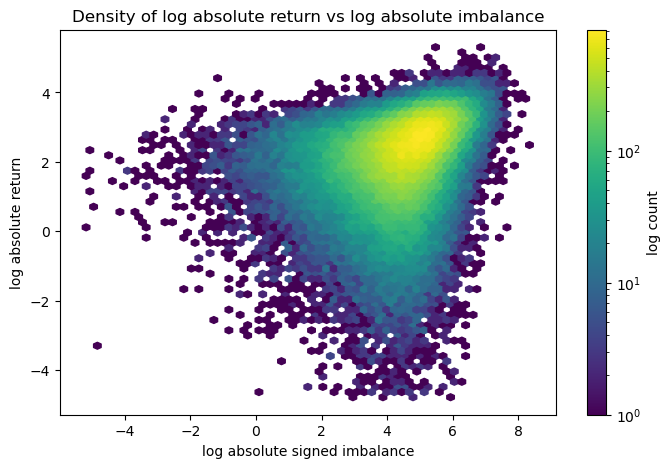

In [15]:
plot_data = analysis[
    ["log_abs_imbalance", "log_abs_return"]
].replace([np.inf, -np.inf], np.nan).dropna().copy()

plt.figure(figsize=(8, 5))

plt.hexbin(
    plot_data["log_abs_imbalance"],
    plot_data["log_abs_return"],
    gridsize=60,
    bins="log",
    cmap="viridis"
)

plt.colorbar(label="log count")
plt.xlabel("log absolute signed imbalance")
plt.ylabel("log absolute return")
plt.title("Density of log absolute return vs log absolute imbalance")
plt.show()

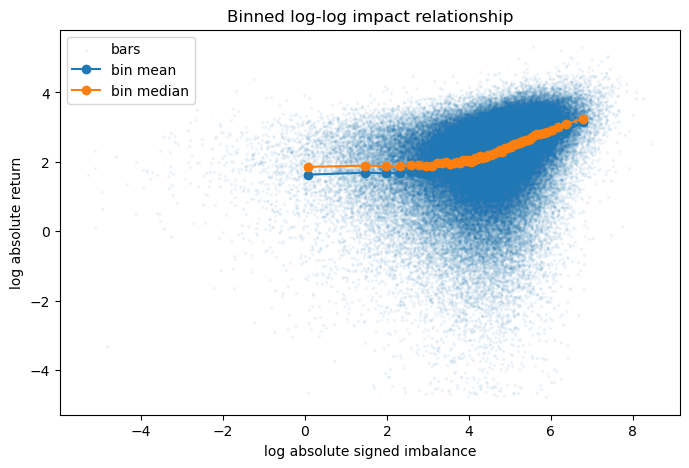

In [16]:
plot_data["imbalance_bin"] = pd.qcut(
    plot_data["log_abs_imbalance"],
    q=60,
    duplicates="drop"
)

binned = (
    plot_data
    .groupby("imbalance_bin", observed=True)
    .agg(
        mean_log_abs_imbalance=("log_abs_imbalance", "mean"),
        mean_log_abs_return=("log_abs_return", "mean"),
        median_log_abs_return=("log_abs_return", "median"),
        p25_log_abs_return=("log_abs_return", lambda x: x.quantile(0.25)),
        p75_log_abs_return=("log_abs_return", lambda x: x.quantile(0.75)),
        count=("log_abs_return", "size"),
    )
    .reset_index(drop=True)
)

plt.figure(figsize=(8, 5))

plt.scatter(
    plot_data["log_abs_imbalance"],
    plot_data["log_abs_return"],
    s=2,
    alpha=0.05,
    label="bars"
)

plt.plot(
    binned["mean_log_abs_imbalance"],
    binned["mean_log_abs_return"],
    marker="o",
    label="bin mean"
)

plt.plot(
    binned["mean_log_abs_imbalance"],
    binned["median_log_abs_return"],
    marker="o",
    label="bin median"
)


plt.xlabel("log absolute signed imbalance")
plt.ylabel("log absolute return")
plt.legend()
plt.title("Binned log-log impact relationship")
plt.show()

In [17]:
mean_bin_fit = fit_regression(
    data=binned,
    target="mean_log_abs_return",
    predictors=["mean_log_abs_imbalance"],
    standardise=[],
    hac_lags=None,
)

median_bin_fit = fit_regression(
    data=binned,
    target="median_log_abs_return",
    predictors=["mean_log_abs_imbalance"],
    standardise=[],
    hac_lags=None,
)

print("Binned mean fit")
print(mean_bin_fit.model.summary())

print("\nBinned median fit")
print(median_bin_fit.model.summary())

Binned mean fit
                             OLS Regression Results                            
Dep. Variable:     mean_log_abs_return   R-squared:                       0.766
Model:                             OLS   Adj. R-squared:                  0.762
Method:                  Least Squares   F-statistic:                     190.0
Date:                 Mon, 29 Jun 2026   Prob (F-statistic):           5.92e-20
Time:                         14:46:36   Log-Likelihood:                 18.836
No. Observations:                   60   AIC:                            -33.67
Df Residuals:                       58   BIC:                            -29.48
Df Model:                            1                                         
Covariance Type:             nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
co

In [18]:
min_bin_number = 12

binned_filtered = binned.iloc[min_bin_number:].copy()

mean_bin_fit = fit_regression(
    data=binned_filtered,
    target="mean_log_abs_return",
    predictors=["mean_log_abs_imbalance"],
    standardise=[],
    hac_lags=None,
)

median_bin_fit = fit_regression(
    data=binned_filtered,
    target="median_log_abs_return",
    predictors=["mean_log_abs_imbalance"],
    standardise=[],
    hac_lags=None,
)

In [19]:
mean_slope = mean_bin_fit.model.params["mean_log_abs_imbalance"]
median_slope = median_bin_fit.model.params["mean_log_abs_imbalance"]

print(f"Minimum bin number: {min_bin_number}")
print(f"Bars used after bin filter: {binned_filtered['count'].sum():,}")
print(f"Bins used: {len(binned_filtered):,}")
print(f"Binned mean slope:   {mean_slope:.3f}")
print(f"Binned median slope: {median_slope:.3f}")

Minimum bin number: 12
Bars used after bin filter: 91,804
Bins used: 48
Binned mean slope:   0.462
Binned median slope: 0.437


## A brief look at the impact response law.

To properly analyse this would imply more lengthy horizons.  Over 5 horizons we can see that the current bar moves strongly in the direction of signed imbalance ratio, and the future responses slowly mean revert.  

In [20]:
impact_response = pd.DataFrame({
    "horizon": [0, 1, 2, 3, 5],
    "mean_signed_response_bps": [
        analysis["signed_current_return_bps"].mean(),
        analysis["signed_future_return_1_bps"].mean(),
        analysis["signed_future_return_2_bps"].mean(),
        analysis["signed_future_return_3_bps"].mean(),
        analysis["signed_future_return_5_bps"].mean(),
    ],
    "median_signed_response_bps": [
        analysis["signed_current_return_bps"].median(),
        analysis["signed_future_return_1_bps"].median(),
        analysis["signed_future_return_2_bps"].median(),
        analysis["signed_future_return_3_bps"].median(),
        analysis["signed_future_return_5_bps"].median(),
    ],
    "count": [
        analysis["signed_current_return_bps"].count(),
        analysis["signed_future_return_1_bps"].count(),
        analysis["signed_future_return_2_bps"].count(),
        analysis["signed_future_return_3_bps"].count(),
        analysis["signed_future_return_5_bps"].count(),
    ],
})

impact_response["standard_error"] = [
    analysis["signed_current_return_bps"].std() / np.sqrt(analysis["signed_current_return_bps"].count()),
    analysis["signed_future_return_1_bps"].std() / np.sqrt(analysis["signed_future_return_1_bps"].count()),
    analysis["signed_future_return_2_bps"].std() / np.sqrt(analysis["signed_future_return_2_bps"].count()),
    analysis["signed_future_return_3_bps"].std() / np.sqrt(analysis["signed_future_return_3_bps"].count()),
    analysis["signed_future_return_5_bps"].std() / np.sqrt(analysis["signed_future_return_5_bps"].count()),
]

impact_response["t_stat"] = (
    impact_response["mean_signed_response_bps"] /
    impact_response["standard_error"]
)

impact_response

,horizon,mean_signed_response_bps,median_signed_response_bps,count,standard_error,t_stat
0,0,9.250004,8.463733,114804,0.040334,229.333667
1,1,-0.227890,-0.014129,114803,0.048695,-4.679979
2,2,-0.359547,0.000000,114802,0.068373,-5.258647
3,3,-0.441301,0.110268,114801,0.083344,-5.294914
4,5,-0.512177,-0.075480,114799,0.106831,-4.794291


In [21]:
def impact_response_by_regime(
    data,
    regime,
    regimes=None,
    horizons=(0, 1, 2, 3, 5),
):
    """
    Summarise signed current/future returns by regime.

    horizon 0 uses signed_current_return_bps.
    horizon h > 0 uses signed_future_return_h_bps.
    """

    if regimes is None:
        regimes = list(data[regime].dropna().unique())

    rows = []

    for regime_value in regimes:
        subset = data[data[regime] == regime_value]

        for h in horizons:
            if h == 0:
                col = "signed_current_return_bps"
            else:
                col = f"signed_future_return_{h}_bps"

            if col not in subset.columns:
                continue

            values = subset[col].dropna()

            if len(values) == 0:
                continue

            rows.append({
                "regime": regime,
                "regime_value": regime_value,
                "horizon": h,
                "count": len(values),
                "mean_signed_response_bps": values.mean(),
                "median_signed_response_bps": values.median(),
                "std": values.std(),
                "standard_error": values.std() / np.sqrt(len(values)),
                "t_stat": values.mean() / (values.std() / np.sqrt(len(values))),
            })

    return pd.DataFrame(rows)

In [22]:
participation_order = [
    "very_high",
    "high",
    "medium",
    "low",
    "very_low",
]

participation_response = impact_response_by_regime(
    data=analysis,
    regime="absolute_imbalance_ratio_regime",
    regimes=participation_order,
    horizons=(0, 1, 2, 3, 5),
)

participation_response

,regime,regime_value,horizon,count,mean_signed_response_bps,median_signed_response_bps,std,standard_error,t_stat
0,absolute_imbalance_ratio_regime,very_high,0,22961,18.609348,17.018149,13.804777,0.091103,204.266516
1,absolute_imbalance_ratio_regime,very_high,1,22961,-0.355287,0.049775,16.467308,0.108674,-3.269278
2,absolute_imbalance_ratio_regime,very_high,2,22961,-0.635704,-0.186501,23.259136,0.153496,-4.141492
3,absolute_imbalance_ratio_regime,very_high,3,22961,-0.740429,0.061470,28.187343,0.186020,-3.980383
4,absolute_imbalance_ratio_regime,very_high,5,22961,-0.963943,-0.566246,36.334579,0.239787,-4.020004
5,absolute_imbalance_ratio_regime,high,0,22961,12.436983,11.530802,12.124878,0.080017,155.429362
6,absolute_imbalance_ratio_regime,high,1,22960,-0.337332,-0.079219,16.176910,0.106760,-3.159716
7,absolute_imbalance_ratio_regime,high,2,22960,-0.512798,-0.223347,22.792765,0.150422,-3.409062
8,absolute_imbalance_ratio_regime,high,3,22959,-0.611287,-0.061693,27.936862,0.184375,-3.315459
9,absolute_imbalance_ratio_regime,high,5,22959,-0.781509,-0.289434,35.651672,0.235290,-3.321471


##  A simple vol forecasting model
Vol forecast looks reasonably well calibrated to a simple model.


In [23]:
# Target: next bar's log range
analysis["next_log_range"] = analysis["log_range"].shift(-1)

# Lagged/smoothed range forecasts
analysis["log_range_ema10"] = analysis["log_range"].ewm(span=10).mean()
analysis["log_range_ema50"] = analysis["log_range"].ewm(span=50).mean()




# Smoothed range plus activity features
result_ema = fit_regression(
    data=analysis,
    target="next_log_range",
    predictors=[
        "log_range_ema10",
        "log_gross_volume",
        "log_absolute_imbalance_ratio",
        "log_duration",
    ],
    standardise=[],
    hac_lags=3,
)

print(f"\n EMA range + activitity: R²={result_ema.model.rsquared:.4f}")
print(result_ema.model.params.round(4).to_string())


 EMA range + activitity: R²=0.3990
const                0.8586
log_range_ema10      0.8339
log_gross_volume    -0.0262
log_absolute_imbalance_ratio   -0.0101
log_duration        -0.0360


In [24]:
print("EMA span optimisation:")
for span in [3, 5, 7, 10, 15, 20, 30, 50]:
    analysis[f'log_range_ema{span}'] = analysis['log_range'].ewm(span=span).mean()
    res = fit_regression(
        data=analysis,
        target='next_log_range',
        predictors=[f'log_range_ema{span}',
                   "log_gross_volume",
                    "log_absolute_imbalance_ratio",
                    "log_duration",],
        standardise=[],
        hac_lags=3
    )
    print(f"EMA {span:>3}: R²={res.model.rsquared:.4f}")

EMA span optimisation:
EMA   3: R²=0.3603
EMA   5: R²=0.3828
EMA   7: R²=0.3928
EMA  10: R²=0.3990
EMA  15: R²=0.4006
EMA  20: R²=0.3987
EMA  30: R²=0.3925
EMA  50: R²=0.3802


In [25]:
# Residual diagnostics for the EMA volatility model

eval_data = analysis[
    [
        "next_log_range",
        "log_range",
        "log_range_ema10",
        "log_gross_volume",
        "log_absolute_imbalance_ratio",
        "log_duration",
        "log_return_bps",
        "high_low_range_bps",
    ]
].replace([np.inf, -np.inf], np.nan).dropna().copy()

eval_data["predicted_log_range"] = result_ema.predict(eval_data)

eval_data["actual_range_bps"] = np.exp(eval_data["next_log_range"])
eval_data["predicted_range_bps"] = np.exp(eval_data["predicted_log_range"])

eval_data["residual"] = (
    eval_data["next_log_range"] - eval_data["predicted_log_range"]
)

eval_data["abs_residual"] = eval_data["residual"].abs()

print("Volatility forecast residual diagnostics")
print(f"Mean residual:       {eval_data['residual'].mean():+.4f}")
print(f"Residual std:        {eval_data['residual'].std():.4f}")
print(f"Mean abs residual:   {eval_data['abs_residual'].mean():.4f}")

print("\nResidual autocorrelations:")
for lag in [1, 2, 3, 5, 10, 20]:
    ac = eval_data["residual"].autocorr(lag)
    print(f"  lag {lag:>2}: {ac:+.4f}")

Volatility forecast residual diagnostics
Mean residual:       +0.0000
Residual std:        0.3480
Mean abs residual:   0.2752

Residual autocorrelations:
  lag  1: +0.0049
  lag  2: -0.0198
  lag  3: -0.0228
  lag  5: -0.0136
  lag 10: -0.0078
  lag 20: +0.0031


In [26]:
candidate_predictors = [
    "log_range",
    "log_range_ema10",
    "log_gross_volume",
    "log_absolute_imbalance_ratio",
    "log_duration",
    "log_return_bps",
]

print("\nResidual correlations with observables:")
for col in candidate_predictors:
    sample = eval_data[["residual", col]].dropna()
    r, p = stats.pearsonr(sample["residual"], sample[col])
    print(f"  {col:25s}: r={r:+.4f}, p={p:.4g}")


Residual correlations with observables:
  log_range                : r=+0.0038, p=0.1925
  log_range_ema10          : r=+0.0000, p=1
  log_gross_volume         : r=-0.0000, p=1
  log_absolute_imbalance_ratio        : r=-0.0000, p=1
  log_duration             : r=-0.0000, p=1
  log_return_bps           : r=-0.0111, p=0.0001769


In [27]:
eval_data["predicted_quintile"] = pd.qcut(
    eval_data["predicted_range_bps"],
    q=5,
    labels=False,
)

print("\nActual range by predicted range quintile:")
display(
    eval_data
    .groupby("predicted_quintile")
    .agg(
        predicted_mean=("predicted_range_bps", "mean"),
        actual_mean=("actual_range_bps", "mean"),
        actual_median=("actual_range_bps", "median"),
        count=("actual_range_bps", "size"),
    )
    .round(2)
)


Actual range by predicted range quintile:


,predicted_mean,actual_mean,actual_median,count
predicted_quintile,,,,
0,14.27,15.32,14.22,22961
1,18.26,19.53,18.23,22960
2,21.16,22.54,21.07,22961
3,24.39,25.71,24.12,22960
4,31.44,33.17,30.58,22961


## Conditioned MR
Test whether next bar return tends to mean revert conditioned on different regimes.

In [28]:
analysis["abs_current_return_bps"] = analysis["current_return_bps"].abs()

mean_reversion_by_abs_return = conditioned_mean_reversion(
    data=analysis,
    conditioning_column="abs_current_return_bps",
    q=5,
    labels=["tiny", "small", "medium", "large", "extreme"],
)

mean_reversion_by_abs_return

,conditioning_bucket,count,mean_conditioning_value,mean_reversal_bps,median_reversal_bps,hit_rate,p10,p25,p75,p90,std,standard_error,t_stat
0,tiny,22961,1.878474,0.142977,-0.000000,0.498585,-18.341548,-9.376415,9.700848,18.827711,15.134191,0.099877,1.431541
1,small,22960,5.824971,0.216769,-0.074032,0.497300,-18.397188,-9.411825,10.085116,19.104657,15.261908,0.100722,2.152162
2,medium,22961,10.267377,0.282035,-0.210298,0.492879,-18.645861,-9.465374,10.216872,20.099311,15.817115,0.104384,2.701909
3,large,22960,16.033233,0.296488,-0.218761,0.494207,-19.267298,-10.139029,10.645400,20.874683,16.353809,0.107928,2.747094
4,extreme,22961,29.223636,0.422010,-0.000000,0.499804,-22.143246,-11.517374,12.240485,24.136973,19.520170,0.128821,3.275932


In [34]:
mean_reversion_by_signed_return = conditioned_mean_reversion(
    data=analysis,
    conditioning_column="current_return_bps",
    q=5,
    labels=["large_down", "small_down", "neutral", "small_up", "large_up"],
)
mean_reversion_by_signed_return

,conditioning_bucket,count,mean_conditioning_value,mean_reversal_bps,median_reversal_bps,hit_rate,p10,p25,p75,p90,std,standard_error,t_stat
0,large_down,22961,-22.567656,0.385651,-0.145235,0.496189,-20.643391,-10.845861,11.402383,22.478538,18.039827,0.119052,3.239350
1,small_down,22960,-8.104790,0.251267,-0.205395,0.493641,-18.437545,-9.465290,10.217126,19.510681,15.507912,0.102345,2.455094
2,neutral,22961,-0.105395,0.145297,0.000000,0.498280,-18.341548,-9.373837,9.711520,18.841851,15.136076,0.099889,1.454584
3,small_up,22960,7.986485,0.247227,-0.079044,0.497038,-18.583288,-9.396414,10.083195,19.701201,15.575116,0.102789,2.405192
4,large_up,22961,22.688931,0.330837,-0.083774,0.497626,-20.761754,-10.662409,11.430485,22.294360,17.972972,0.118611,2.789263


## Mutual Information - nonlinear analysis
This section attempts to apply information theory to the time series.  I used sklearn to do the mi estimation.  Rather than calculating a conditional outcome on the previous series as in the typical binary case, this method uses k nearest neigbours to calculate the predictability of the future return distribution (ie not directionality of the realised returns precisely, but a more general measure of conditional information).  Results show that mutual information is generally positive for many lags, with a slowly and approximately decaying function of lag distance whilst correlation is close to zero.

Computing MI profiles...

MI Profile — raw return → future return:
 lag       mi  mi_null  mi_excess
   1 0.007828 0.000000   0.007828
   2 0.008387 0.000000   0.008387
   3 0.007735 0.001831   0.005903
   4 0.008759 0.000000   0.008759
   5 0.006429 0.000000   0.006429
   6 0.007821 0.000000   0.007821
   7 0.007661 0.000638   0.007023
   8 0.005251 0.000000   0.005251
   9 0.006883 0.001704   0.005179
  10 0.006133 0.000422   0.005711
  11 0.004979 0.000000   0.004979
  12 0.006949 0.000000   0.006949
  13 0.005705 0.000099   0.005606
  14 0.006443 0.000105   0.006338
  15 0.006372 0.000901   0.005471
  16 0.007870 0.000000   0.007870
  17 0.005154 0.000533   0.004620
  18 0.004803 0.000100   0.004703
  19 0.004947 0.000000   0.004947
  20 0.004519 0.000000   0.004519


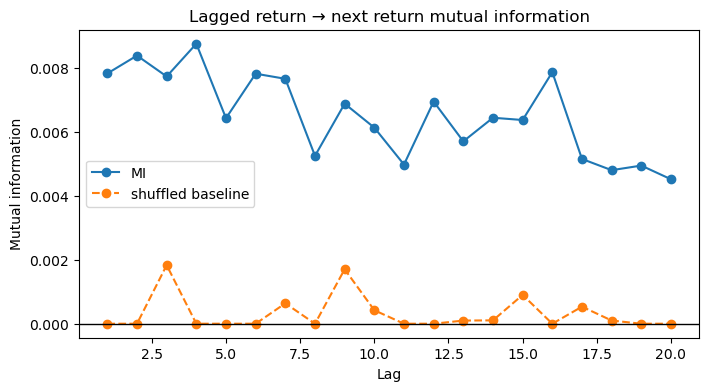

In [35]:
from sklearn.feature_selection import mutual_info_regression

def mi_lag_profile(series, target, max_lag=20, n_neighbors=10):
    """
    Compute MI between lagged series and target at each lag.  Ouputs a DataFrame with lag, MI value,
    and a naive permutation-based noise floor.
    """
    results = []
    
    for lag in range(1, max_lag + 1):
        lagged = series.shift(lag)
        sample = pd.concat(
            [lagged.rename("predictor"), target.rename("target")],
            axis=1,
        ).replace([np.inf, -np.inf],np.nan).dropna()
        
        if len(sample) < 500:
            continue
            
        X = sample[["predictor"]].to_numpy()
        y = sample["target"].to_numpy()
        
        mi = mutual_info_regression(X, y, n_neighbors=n_neighbors,
                                    random_state=42)[0]
        
        # Noise floor: shuffle X and recompute (single permutation)
        shuffled = sample["predictor"].sample(
            frac=1,
            replace=False,
            random_state=42 + lag,
        ).to_numpy().reshape(-1, 1)

        mi_null = mutual_info_regression(shuffled, y, 
                                          n_neighbors=n_neighbors,
                                          random_state=42)[0]
        results.append({
            'lag': lag,
            'n': len(sample),
            'mi': mi, 
            'mi_null': mi_null,
            'mi_excess': mi - mi_null
        })
    
    return pd.DataFrame(results)

print("Computing MI profiles...")

# Target: 1-bar ahead return
future_ret = analysis['future_return_1_bps']

# predictors: raw return.  could obv use other predictors
mi_return   = mi_lag_profile(analysis['current_return_bps'], future_ret, max_lag=20, n_neighbors=10)

print("\nMI Profile — raw return → future return:")
print(mi_return[['lag','mi','mi_null','mi_excess']].to_string(index=False))

plt.figure(figsize=(8, 4))

plt.plot(
    mi_return["lag"],
    mi_return["mi"],
    marker="o",
    label="MI",
)

plt.plot(
    mi_return["lag"],
    mi_return["mi_null"],
    marker="o",
    linestyle="--",
    label="shuffled baseline",
)

plt.axhline(0, color="black", linewidth=1)
plt.xlabel("Lag")
plt.ylabel("Mutual information")
plt.title("Lagged return → next return mutual information")
plt.legend()
plt.show()

In [29]:
rows = []

for lag in range(1, 21):
    lagged = analysis["current_return_bps"].shift(lag)
    target = analysis["future_return_1_bps"]

    sample = pd.concat(
        [lagged.rename("lagged_return"), target.rename("future_return")],
        axis=1,
    ).dropna()

    rows.append({
        "lag": lag,
        "pearson": sample["lagged_return"].corr(
            sample["future_return"],
            method="pearson",
        ),
        "spearman": sample["lagged_return"].corr(
            sample["future_return"],
            method="spearman",
        ),
    })

return_corr_profile = pd.DataFrame(rows)
return_corr_profile

mi_vs_corr = mi_return.merge(return_corr_profile, on="lag")
mi_vs_corr

,lag,n,mi,mi_null,mi_excess,pearson,spearman
0,1,114802,0.007828,0.000000,0.007828,-0.006686,-0.006599
1,2,114801,0.008387,0.000000,0.008387,-0.006346,-0.004859
2,3,114800,0.007735,0.001831,0.005903,-0.003587,-0.006222
3,4,114799,0.008759,0.000000,0.008759,0.001340,0.000579
4,5,114798,0.006429,0.000000,0.006429,-0.006631,-0.006529
5,6,114797,0.007821,0.000000,0.007821,-0.005512,-0.007115
6,7,114796,0.007661,0.000638,0.007023,0.002645,0.002705
7,8,114795,0.005251,0.000000,0.005251,0.006299,0.002944
8,9,114794,0.006883,0.001704,0.005179,-0.003920,-0.003477
9,10,114793,0.006133,0.000422,0.005711,-0.007563,-0.004582


Next step is to look at multi period prediction.  Single lag MI profile suggest weak dependence across several lags, so logical to see how multiperiod directional histories are related to future returns or other variables.

I defined a neutral state between the 47 and 53 percent quantiles.  It is also possible to define just two states, but thought it made sense to take out the bars where returns are close to zero.  

In [77]:
lower_threshold = analysis["current_return_bps"].quantile(0.47)
upper_threshold = analysis["current_return_bps"].quantile(0.53)

analysis["return_direction_3state"] = np.select(
    [
        analysis["current_return_bps"] <= lower_threshold,
        analysis["current_return_bps"] >= upper_threshold,
    ],
    [
        -1,
        1,
    ],
    default=0,
)

analysis["future_direction_3state"] = np.select(
    [
        analysis["future_return_1_bps"] <= lower_threshold,
        analysis["future_return_1_bps"] >= upper_threshold,
    ],
    [
        -1,
        1,
    ],
    default=0,
)

In [84]:
from sklearn.metrics import mutual_info_score, normalized_mutual_info_score

def make_direction_history(data, history_length, direction_column="return_direction_3state"):
    pieces = []

    for lag in range(history_length, 0, -1):
        pieces.append(
            data[direction_column]
            .shift(lag)
            .astype("Int64")
            .astype(str)
        )

    if len(pieces) == 1:
        return pieces[0]

    return pieces[0].str.cat(pieces[1:], sep="_")


rows = []

for history_length in range(1, 8):
    history = make_direction_history(analysis, history_length)

    sample = pd.DataFrame({
        "history": history,
        "future_direction": analysis["future_direction_3state"],
    }).replace("<NA>", np.nan).dropna()

    # Optional: neutral future outcomes to make target meaningful up/down
    sample = sample[sample["future_direction"] != 0].copy()

    mi = mutual_info_score(
        sample["history"],
        sample["future_direction"],
    )

    nmi = normalized_mutual_info_score(
        sample["history"],
        sample["future_direction"],
    )

    shuffled = sample["history"].sample(
        frac=1,
        replace=False,
        random_state=42 + history_length,
    )

    mi_null = mutual_info_score(
        shuffled,
        sample["future_direction"],
    )

    rows.append({
        "history_length": history_length,
        "n": len(sample),
        "states": sample["history"].nunique(),
        "mi": mi,
        "mi_null": mi_null,
        "mi_excess": mi - mi_null,
        "nmi": nmi,
    })

multi_period_mi = pd.DataFrame(rows)
multi_period_mi

,history_length,n,states,mi,mi_null,mi_excess,nmi
0,1,107927,3,0.000020,0.000003,0.000017,0.000025
1,2,107928,11,0.000051,0.000041,0.000010,0.000041
2,3,107928,30,0.000139,0.000088,0.000051,0.000084
3,4,107928,85,0.000418,0.000441,-0.000023,0.000199
4,5,107928,241,0.001116,0.001076,0.000040,0.000439
5,6,107928,669,0.003308,0.003162,0.000146,0.001111
6,7,107928,1727,0.009042,0.009364,-0.000322,0.002649


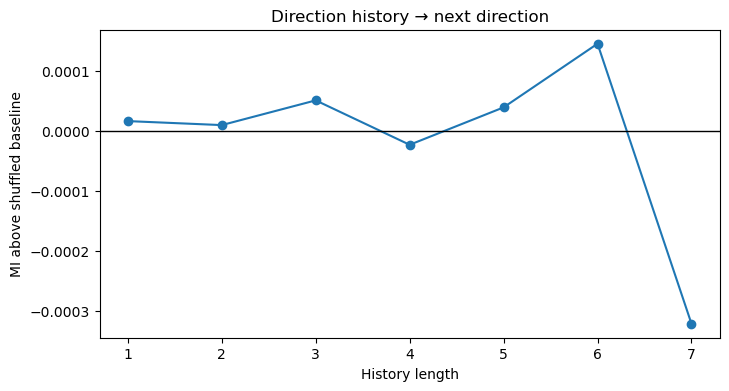

In [85]:
plt.figure(figsize=(8, 4))

plt.plot(
    multi_period_mi["history_length"],
    multi_period_mi["mi_excess"],
    marker="o",
)

plt.axhline(0, color="black", linewidth=1)
plt.xlabel("History length")
plt.ylabel("MI above shuffled baseline")
plt.title("Direction history → next direction")
plt.show()

In [80]:
# Inspect which two-period histories drive the one-bar result.
history_length = 2

analysis["direction_history"] = make_direction_history(
    analysis,
    history_length=history_length,
)

history_summary = (
    analysis
    .dropna(subset=["direction_history", "future_return_1_bps"])
    .groupby("direction_history")["future_return_1_bps"]
    .agg(["count", "mean", "median", "std"])
    .query("count >= 200")
    .reset_index()
)

history_summary["standard_error"] = (
    history_summary["std"] / np.sqrt(history_summary["count"])
)

history_summary["t_stat"] = (
    history_summary["mean"] / history_summary["standard_error"]
)

history_summary.sort_values("t_stat")

,direction_history,count,mean,median,std,standard_error,t_stat
8,1_1,25503,-0.369892,-0.290421,16.572879,0.103777,-3.564287
5,0_1,3219,-0.398366,-0.210968,15.071367,0.265639,-1.499651
2,-1_1,25234,-0.013304,-0.115342,16.496657,0.103849,-0.128106
4,0_0,436,0.054508,0.217723,13.439047,0.643614,0.084691
0,-1_-1,25564,0.080847,-0.135636,17.176975,0.107432,0.752540
3,0_-1,3233,0.241092,0.000000,15.414821,0.271104,0.889297
7,1_0,3294,0.291609,0.101514,14.693059,0.256006,1.139069
6,1_-1,25160,0.133944,0.039557,16.446358,0.103685,1.291845
1,-1_0,3158,0.457329,0.278200,15.346761,0.273093,1.674626


In [81]:
# Check whether the same history effects persist across longer horizons.
history_length = 2

analysis["direction_history"] = make_direction_history(
    analysis,
    history_length=history_length,
    direction_column="return_direction_3state",
)

rows = []

for h in [1, 2, 3, 5]:
    future_col = f"future_return_{h}_bps"

    for history, group in analysis.groupby("direction_history", observed=True):
        if history == "<NA>" or future_col not in group.columns:
            continue

        future_returns = group[future_col].dropna()

        if len(future_returns) < 200:
            continue

        rows.append({
            "history_length": history_length,
            "horizon": h,
            "direction_history": history,
            "count": len(future_returns),
            "mean_future_return_bps": future_returns.mean(),
            "median_future_return_bps": future_returns.median(),
            "std": future_returns.std(),
            "standard_error": future_returns.std() / np.sqrt(len(future_returns)),
            "t_stat": future_returns.mean() / (
                future_returns.std() / np.sqrt(len(future_returns))
            ),
        })

history_horizon_summary = pd.DataFrame(rows)

history_horizon_summary.sort_values(["horizon", "t_stat"])

,history_length,horizon,direction_history,count,mean_future_return_bps,median_future_return_bps,std,standard_error,t_stat
8,2,1,1_1,25503,-0.369892,-0.290421,16.572879,0.103777,-3.564287
5,2,1,0_1,3219,-0.398366,-0.210968,15.071367,0.265639,-1.499651
2,2,1,-1_1,25234,-0.013304,-0.115342,16.496657,0.103849,-0.128106
4,2,1,0_0,436,0.054508,0.217723,13.439047,0.643614,0.084691
0,2,1,-1_-1,25564,0.080847,-0.135636,17.176975,0.107432,0.752540
3,2,1,0_-1,3233,0.241092,0.000000,15.414821,0.271104,0.889297
7,2,1,1_0,3294,0.291609,0.101514,14.693059,0.256006,1.139069
6,2,1,1_-1,25160,0.133944,0.039557,16.446358,0.103685,1.291845
1,2,1,-1_0,3158,0.457329,0.278200,15.346761,0.273093,1.674626
17,2,2,1_1,25503,-0.507167,-0.345417,23.218764,0.145393,-3.488249


In [74]:
history_horizon_summary.pivot(
    index="direction_history",
    columns="horizon",
    values="mean_future_return_bps",
)

horizon,1,2,3,5
direction_history,,,,
-1_-1,0.080847,0.228344,0.205318,0.440918
-1_0,0.457329,0.346666,0.267237,-0.336654
-1_1,-0.013304,-0.055943,-0.117059,-0.071438
0_-1,0.241092,0.317179,-0.341240,-0.583951
0_0,0.054508,0.263363,1.051903,1.348178
0_1,-0.398366,-0.567528,-0.826628,-0.173450
1_-1,0.133944,0.099818,0.301406,0.054537
1_0,0.291609,0.224605,0.133393,0.389126
1_1,-0.369892,-0.507167,-0.593863,-0.836867


In [76]:
history_horizon_summary.pivot(
    index="direction_history",
    columns="horizon",
    values="t_stat",
)

horizon,1,2,3,5
direction_history,,,,
-1_-1,0.752540,1.505209,1.112769,1.885651
-1_0,1.674626,0.925155,0.583645,-0.575322
-1_1,-0.128106,-0.382444,-0.659859,-0.311399
0_-1,0.889297,0.826063,-0.734172,-0.991029
0_0,0.084691,0.284985,0.920165,0.953760
0_1,-1.499651,-1.551904,-1.818823,-0.300711
1_-1,1.291845,0.689278,1.693162,0.236246
1_0,1.139069,0.616059,0.303805,0.698301
1_1,-3.564287,-3.488249,-3.354603,-3.703867


The clearest two-period pattern is up-up: two positive bars are followed by a small negative average return. The t-stat is meaningful because we have a large sample. The corresponding down-down bounce is weaker, suggesting asymmetry in short-horizon mean reversion.  The return and the t-stats improve marginally at longer horizons.